In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('/content/Crop_recommendation.csv')
data.shape

(2200, 8)

In [3]:
data.head(5)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [6]:
data.describe(include='all')

,N,P,K,temperature,humidity,ph,rainfall,label
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rice
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655,NaN
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389,NaN
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,NaN
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686,NaN
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624,NaN
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508,NaN


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [9]:
data.dtypes

,0
N,int64
P,int64
K,int64
temperature,float64
humidity,float64
ph,float64
rainfall,float64
label,object


**Dataset Overview:**

**Composition**: The dataset comprises 2200 entries with 8 columns. These columns include N (Nitrogen), P (Phosphorus), K (Potassium), temperature, humidity, pH, rainfall, and label (type of crop).



**Data Representation**: Each row in the dataset represents different conditions and the type of crop grown under those conditions.



**Data Types**: The dataset includes a mix of both integer and floating-point data types.



**Data Quality:** There are no null values in any of the columns, indicating a complete dataset with no missing information.

In [12]:
data.select_dtypes(include=['int64','float64']).describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


**Summary Statistics:**



**Nutrient Levels:** The levels of nutrients like Nitrogen (N), Phosphorus (P), and Potassium (K) vary widely, indicating a diverse range of crop nutrient requirements.




**Temperature:** The dataset shows a temperature range from 8.83°C to 43.68°C, indicating it covers a broad spectrum of climatic conditions.





**Humidity:** Humidity in the dataset varies between 14.26% and 99.98%, signifying a wide array of environmental conditions.




**pH Levels:** pH levels range from 3.50 to 9.94, encompassing conditions from acidic to alkaline soil types.





**Rainfall:** Rainfall measurements vary from 20.21 mm to 298.56 mm, suggesting the dataset includes crops with diverse water requirements.

## Data Visualization

In [29]:
data.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

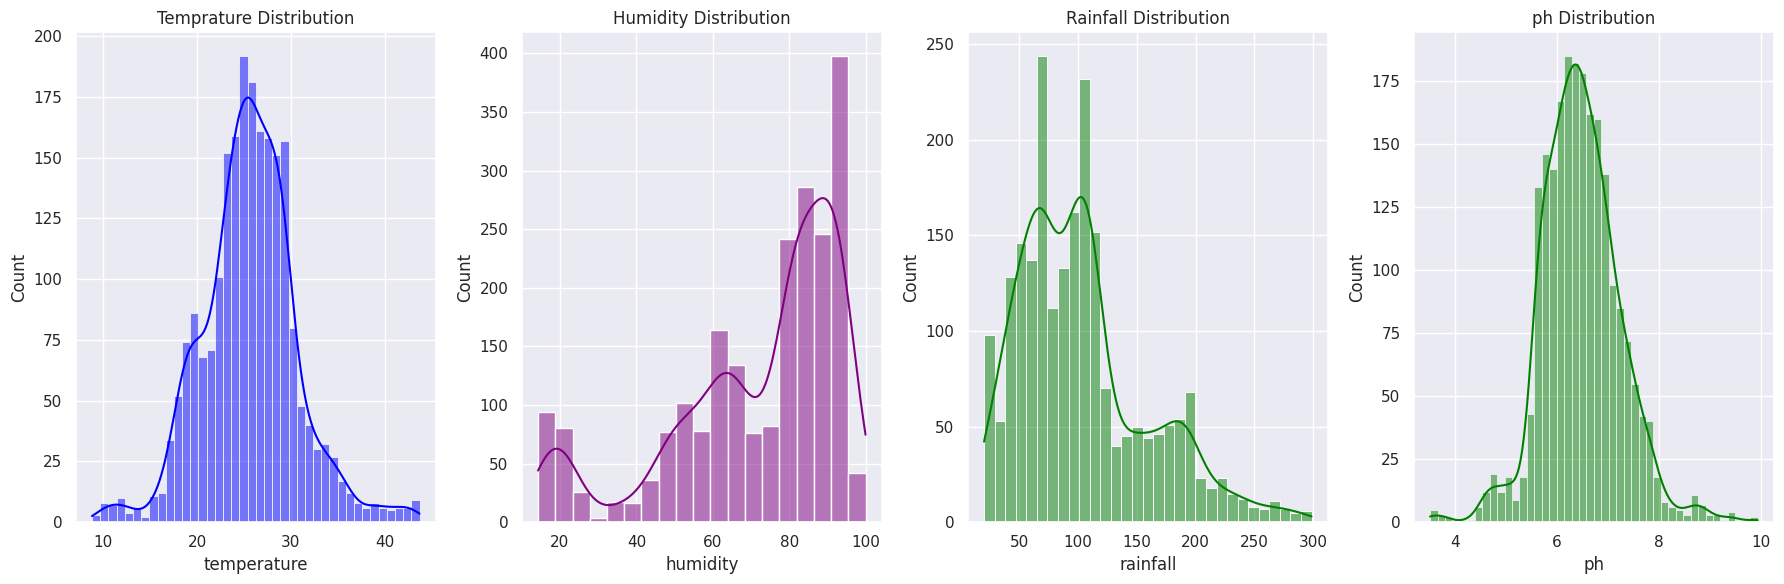

In [30]:
#sets a clean white background with gridlines for all your plots.
sns.set(style='darkgrid')

fig, axes = plt.subplots(1, 4, figsize=(18,6))

sns.histplot(data['temperature'], kde=True, color="blue", ax=axes[0])
axes[0].set_title('Temprature Distribution')

sns.histplot(data['humidity'], kde=True, color="purple", ax=axes[1])
axes[1].set_title("Humidity Distribution")

sns.histplot(data['rainfall'], kde=True, color="green", ax=axes[2])
axes[2].set_title("Rainfall Distribution")

sns.histplot(data['ph'], kde=True, color="green", ax=axes[3])
axes[3].set_title("ph Distribution")

#utomatically adjusts spacing between subplots so titles and labels don’t overlap.
plt.tight_layout()
plt.show()


**Data Distributions Overview:**



**Temperature Distribution:** This histogram illustrates the distribution of temperature across the dataset. The data appears to be fairly normally distributed, signifying a wide range of temperatures suitable for different crops.



**Humidity Distribution**: The histogram for humidity demonstrates a wide range, with a slight skewness towards higher humidity levels.



**Rainfall Distribution**: The distribution of rainfall is skewed, suggesting that most crops in the dataset are cultivated in regions with moderate to high rainfall.


**ph Distribution:** This histogram illustrates the distribution of ph across the dataset. The data appears to be fairly normally distributed, signifying a wide range of ph suitable for different crops.

These visualizations are instrumental in understanding the environmental conditions under which various crops are grown in the dataset.

## ANOVA Analysis for Humidity

In [31]:
data.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [35]:
data['label'].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


In [40]:
from scipy.stats import f_oneway

In [42]:
crop_types = data['label'].unique()
humidity_lists = [data[data['label'] == crop]['humidity'] for crop in crop_types]
anova_result_humidity = f_oneway(*humidity_lists)
anova_result_humidity

F_onewayResult(statistic=np.float64(3103.708891217502), pvalue=np.float64(0.0))

This line performs a one-way ANOVA test using the SciPy function f_oneway().

f_oneway() tests whether there are statistically significant differences between the means of multiple groups (in this case, humidity across crop types).

The * (asterisk) unpacks the list — so instead of passing one list of lists, it passes each crop’s humidity list as a separate argument.


**Results:**

**F-Statistic:** The F-Statistic is 3103.71, which indicates a significant variance ratio between the different crops' humidity levels.

**P-Value**: The P-Value is 0.0, which is extremely small.

**Interpretation:**

The extremely low P-Value suggests that there are statistically significant differences in the average humidity levels for different crops. This indicates that crops vary significantly in their preference for environmental humidity.

These results highlight the importance of humidity as a factor in agricultural crop selection and cultivation.

## ANOVA Analysis for Rainfall

In [47]:
crop_types = data['label'].unique()

rainfall_lists = [data[data['label'] == crop]['rainfall'] for crop in crop_types]

anova_result_rainfall = f_oneway(*rainfall_lists)

anova_result_rainfall

F_onewayResult(statistic=np.float64(605.5279661441423), pvalue=np.float64(0.0))

## ANOVA Analysis for Temperature

In [53]:
# Ensure crop_types is defined from your DataFrame 'df'
crop_types = data['label'].unique()

# Preparing a list of temperature values for each crop type
temperature_lists = [data[data['label'] == crop]['temperature'] for crop in crop_types]

# Performing the ANOVA test for temperature
anova_result_temperature = f_oneway(*temperature_lists)

anova_result_temperature

F_onewayResult(statistic=np.float64(102.18698122995393), pvalue=np.float64(4.019323818173197e-305))

## Anova for ph

In [55]:
# Ensure crop_types is defined from your DataFrame 'df'
crop_types = data['label'].unique()

# Preparing a list of temperature values for each crop type
ph_lists = [data[data['label'] == crop]['ph'] for crop in crop_types]

# Performing the ANOVA test for temperature
anova_result_ph = f_oneway(*ph_lists)

anova_result_ph

F_onewayResult(statistic=np.float64(60.344033529413736), pvalue=np.float64(6.493161898840498e-199))